# Google Stock Price Analysis & Prediction
### End-to-end analysis using the OSEMN framework
---
**Author:** Michał Mańkowski
**Stock:** Alphabet Corporation (GOOGL)
**Stack:** Python, yfinance, Pandas, Scikit-learn, Matplotlib

##  O — Obtain
### Downloading Microsoft stock data via yfinance API

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Download Google stock data (20 years)
ticker = yf.Ticker("GOOGL")
df = ticker.history(period="20y")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (5030, 7)

First 5 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-22 00:00:00-04:00,9.129997,9.258565,9.065466,9.206940,343831824,0.0,0.0
2006-05-23 00:00:00-04:00,9.287851,9.527859,9.271717,9.321854,358960680,0.0,0.0
2006-05-24 00:00:00-04:00,9.365785,9.516939,9.223320,9.462583,381769848,0.0,0.0
2006-05-25 00:00:00-04:00,9.408723,9.506018,9.240692,9.505769,327456216,0.0,0.0
2006-05-26 00:00:00-04:00,9.544488,9.577499,9.432301,9.465064,146533320,0.0,0.0


### Dataset Overview
- **20 years** of Microsoft stock data
- **8 columns:** Open, High, Low, Close, Volume, Dividends, Stock Splits, Capital Gains
- Data sourced directly from Yahoo Finance API

## S — Scrub
### Checking data quality and cleaning

In [2]:
print("Column types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Column types:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

Missing values:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Basic statistics:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,5030.000000,5030.000000,5030.000000,5030.000000,5.030000e+03,5030.000000,5030.000000
mean,64.466622,65.176583,63.773882,64.501937,8.242007e+07,0.000326,0.004373
std,68.195233,69.028317,67.405734,68.276685,8.587675e+07,0.008172,0.283396
min,6.515468,6.685734,6.137959,6.389631,9.312000e+06,0.000000,0.000000
25%,14.803823,14.907074,14.693561,14.791537,2.911400e+07,0.000000,0.000000
50%,37.667918,37.974395,37.441295,37.690735,4.505180e+07,0.000000,0.000000
75%,95.634580,97.501645,94.248532,95.731285,1.032976e+08,0.000000,0.000000
max,399.920013,408.609985,396.359985,402.619995,9.305605e+08,0.210000,20.000000


### Scrub Observations
- **0 missing values** — clean dataset, no imputation needed
- Data ready for exploration

## E — Explore
### Exploratory Data Analysis — price trends, volume and returns

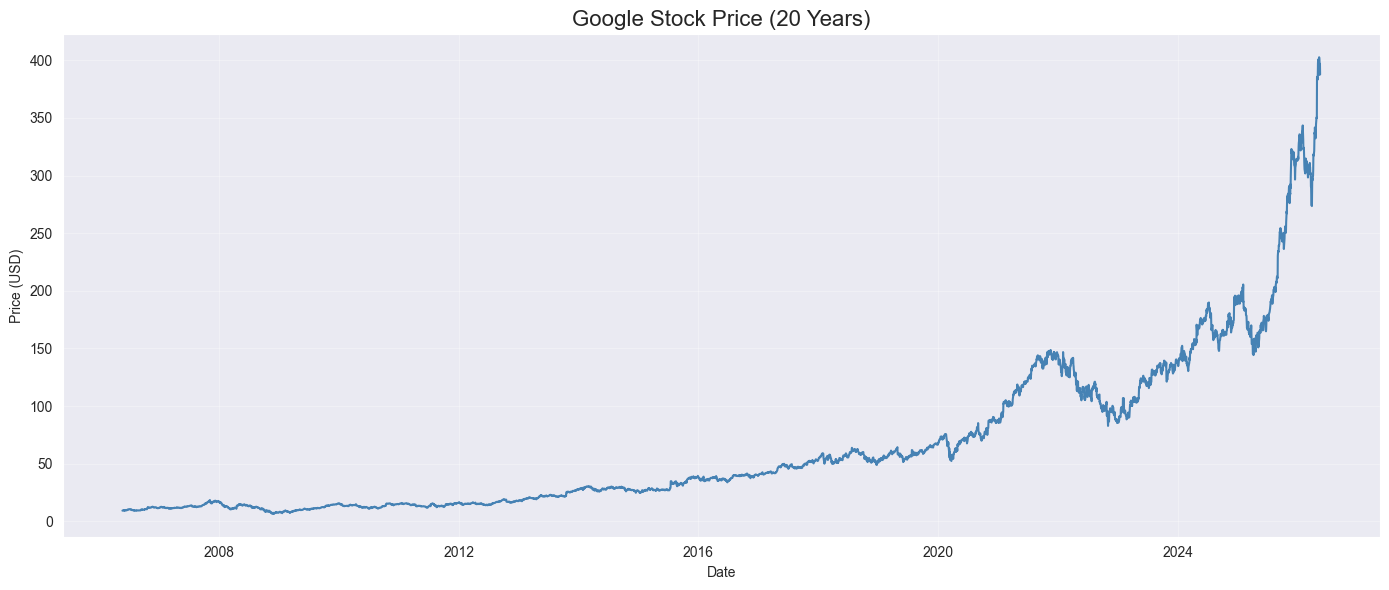

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
plt.title('Google Stock Price (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EDA Observations
- **Flat growth 2005-2016** — slow and steady growth in early years
- **Strong acceleration post-2016** — Google Cloud, YouTube
  and advertising dominance
- **Dip 2022** — rate hikes and ad revenue slowdown
- **Explosive growth 2024-2025** — AI boom, Gemini launch
  and strong cloud growth pushing price to all-time highs ~$400
- **Most aggressive recent growth** among the three stocks analyzed
  (Apple, Microsoft,

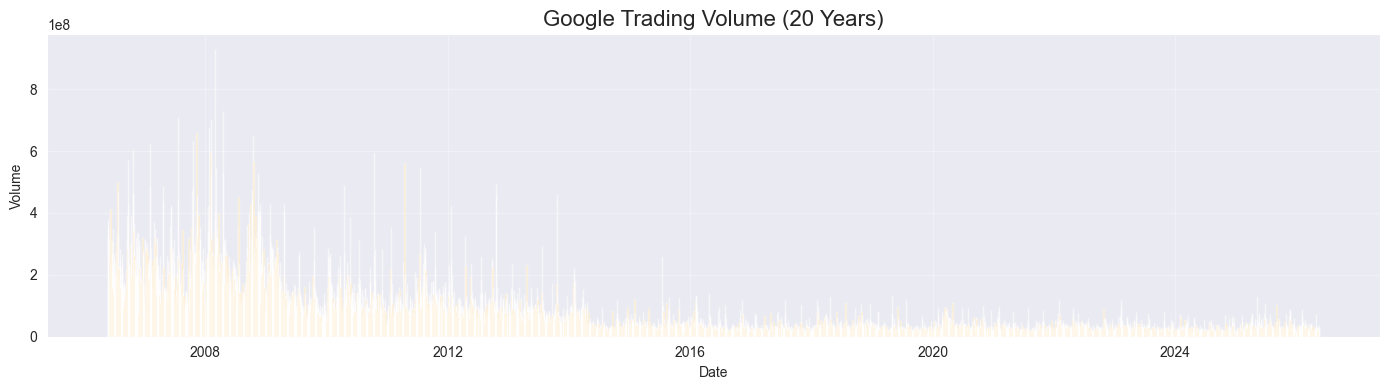

In [6]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='orange', alpha=0.6, width=1)
plt.title('Google Trading Volume (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Highest trading volume **2007-2009** — financial crisis
  caused massive uncertainty and active trading
- **Declining volume 2010s** — stabilization period,
  fewer traders actively buying/selling
- **Very low volume post-2016** — despite massive price growth,
  very few shares changing hands — strong institutional
  buy-and-hold behavior
- Similar pattern to Microsoft — growing price

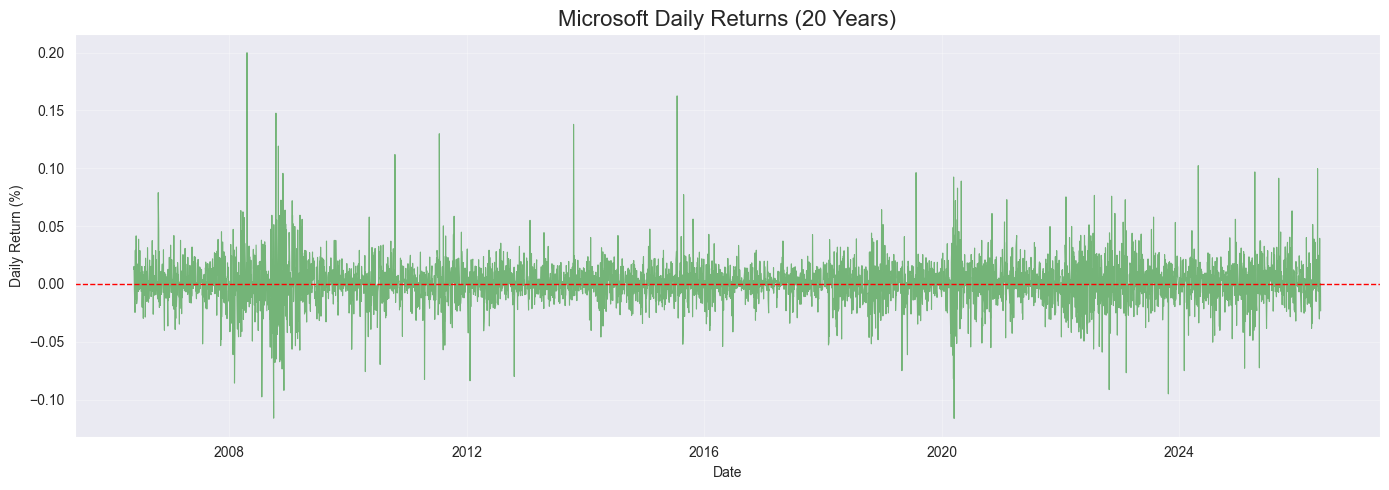

Average daily return: 0.0009
Max daily return: 0.1999
Min daily return: -0.1163
Volatility (std): 0.0187


In [7]:
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Daily_Return'], color='green', alpha=0.5, linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Microsoft Daily Returns (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average daily return: {df['Daily_Return'].mean():.4f}")
print(f"Max daily return: {df['Daily_Return'].max():.4f}")
print(f"Min daily return: {df['Daily_Return'].min():.4f}")
print(f"Volatility (std): {df['Daily_Return'].std():.4f}")

- Average daily return: **+0.09%** — between Apple (+0.12%)
  and Microsoft (+0.08%)
- Max single day gain: **+19.99%** — highest among all three stocks!
  likely post strong earnings or AI announcement
- Max single day loss: **-11.63%** — lowest loss among all three stocks
  — surprisingly resilient during crashes
- Daily volatility: **1.87%** — highest among all three stocks
  — Google is the most volatile of the three

### Three Stocks Comparison
| Metric | Apple (AAPL) | Microsoft (MSFT) | Google (GOOGL) |
|--------|-------------|-----------------|----------------|
| Avg daily return | +0.12% | +0.08% | +0.09% |
| Max gain | +15.33% | +18.60% | +19.99% |
| Max loss | -17.92% | -14.74% | -11.63% |
| Volatility | 1.79% | 1.74% | 1.87% |

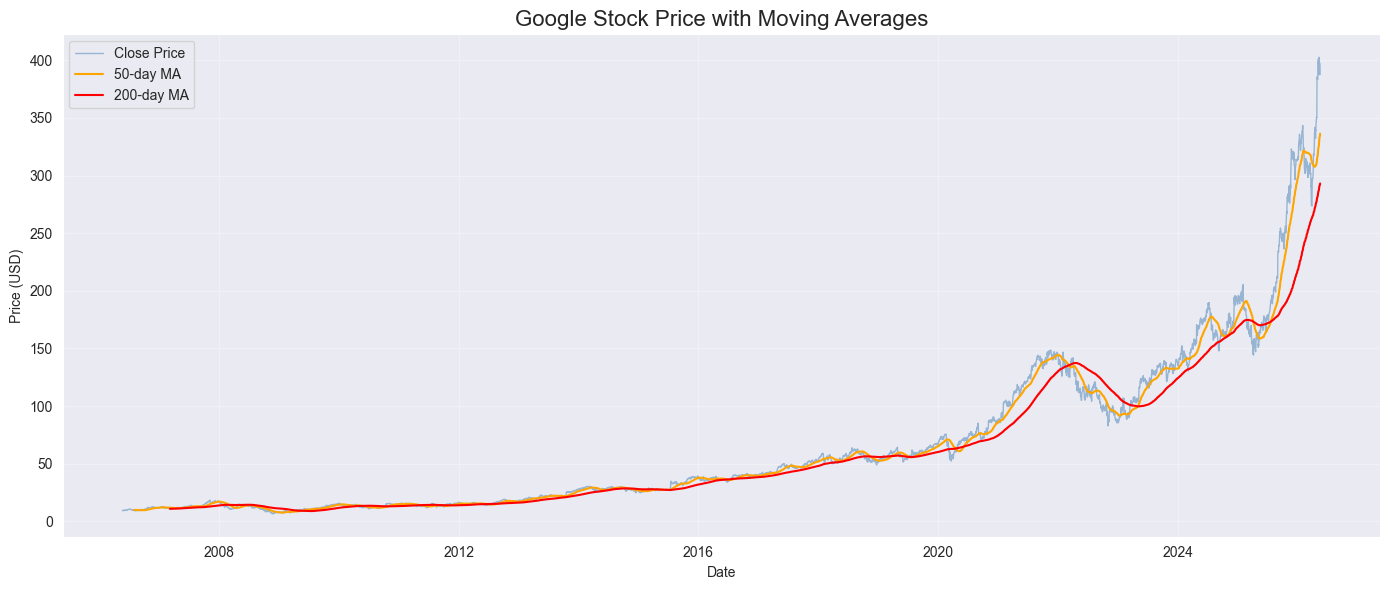

In [9]:
# Moving averages
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', alpha=0.5, linewidth=1, label='Close Price')
plt.plot(df.index, df['MA_50'], color='orange', linewidth=1.5, label='50-day MA')
plt.plot(df.index, df['MA_200'], color='red', linewidth=1.5, label='200-day MA')
plt.title('Google Stock Price with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Feature engineering
df['Target'] = df['Close'].shift(-1)  # next day price

df['Return_5d'] = df['Close'].pct_change(5)   # 5 day return
df['Return_20d'] = df['Close'].pct_change(20) # 20 day return
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()
df['Volatility'] = df['Daily_Return'].rolling(20).std()

# Drop NaN rows created by rolling windows
df_model = df.dropna()

# Features and target
features = ['Close', 'Volume', 'MA_50', 'MA_200',
            'Return_5d', 'Return_20d', 'Volatility']

X = df_model[features]
y = df_model['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4830, 7)
Target shape: (4830,)


In [11]:
# Split data - time series so NO shuffle!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Model 1 - Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2 - Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Results
print("\n=== Linear Regression ===")
print(f"MAE: ${mean_absolute_error(y_test, lr_pred):.2f}")
print(f"R²: {r2_score(y_test, lr_pred):.4f}")

print("\n=== Random Forest ===")
print(f"MAE: ${mean_absolute_error(y_test, rf_pred):.2f}")
print(f"R²: {r2_score(y_test, rf_pred):.4f}")

Training set: (3864, 7)
Test set: (966, 7)

=== Linear Regression ===
MAE: $2.44
R²: 0.9974

=== Random Forest ===
MAE: $41.52
R²: -0.0484


In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Model 3 - Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# Model 4 - KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

# Results
print("=== Gradient Boosting ===")
print(f"MAE: ${mean_absolute_error(y_test, gb_pred):.2f}")
print(f"R²: {r2_score(y_test, gb_pred):.4f}")

print("\n=== KNN ===")
print(f"MAE: ${mean_absolute_error(y_test, knn_pred):.2f}")
print(f"R²: {r2_score(y_test, knn_pred):.4f}")

=== Gradient Boosting ===
MAE: $43.19
R²: -0.1036

=== KNN ===
MAE: $109.72
R²: -2.4398


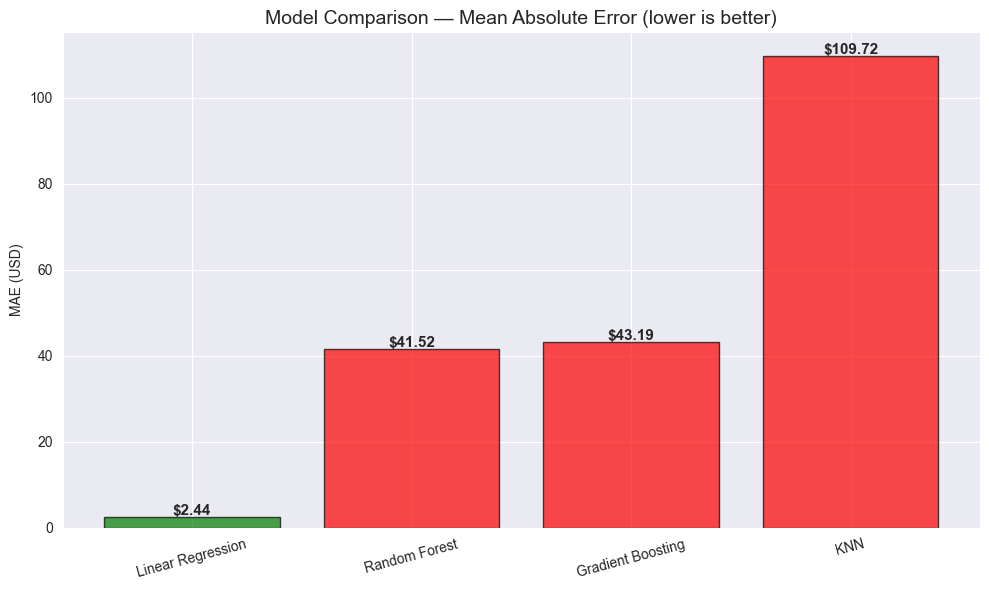

In [13]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'KNN']
mae_scores = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, gb_pred),
    mean_absolute_error(y_test, knn_pred)
]

plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'red', 'red']
bars = plt.bar(models, mae_scores, color=colors, alpha=0.7, edgecolor='black')
plt.title('Model Comparison — Mean Absolute Error (lower is better)', fontsize=14)
plt.ylabel('MAE (USD)')
plt.xticks(rotation=15)

# Add values on bars
for bar, score in zip(bars, mae_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${score:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

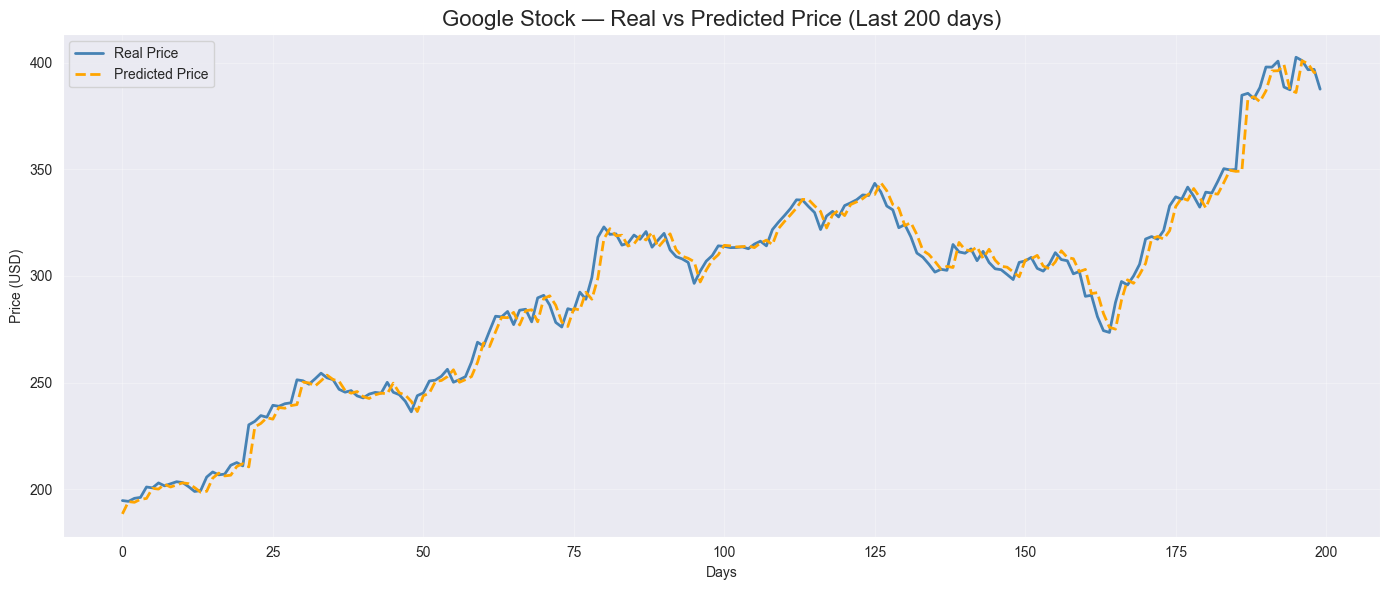

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-200:], color='steelblue', label='Real Price', linewidth=2)
plt.plot(lr_pred[-200:], color='orange', linestyle='--', label='Predicted Price', linewidth=2)
plt.title('Google Stock — Real vs Predicted Price (Last 200 days)', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

### Key Findings

- Google shows the **most aggressive recent growth** among all three
  stocks analyzed, driven by AI boom and Gemini launch in 2024-2025
- **Linear Regression wins** with MAE $2.44 and R² 0.9974 —
  the best R² score across all three stocks analyzed
- Google is the **most volatile** stock (1.87%) but also has the
  **lowest single day loss** (-11.63%) — suggesting strong
  recovery ability after crashes

### Cross-Stock Conclusion
After analyzing Apple, Microsoft and Google, one consistent finding
emerges: **Linear Regression outperforms all complex ML models**
for next-day stock price prediction, regardless of the company.

This is because stock prices follow a near-perfect linear pattern:
tomorrow's price ≈ today's price + small change.

### Investment Insight
- **Apple** — most consistent daily returns (+0.12%), best for
  steady long-term growth
- **Microsoft** — most stable (lowest volatility 1.74%),
  best for risk-averse investors
- **Google** — highest potential gains (+19.99% max day) but
  also highest volatility — best for growth-oriented investors